Welcome to the Stock Investment Analysis Program


Please enter your WRDS username:  rachellzy


Loading library list...
Done
Successfully connected to WRDS.

Please choose an option:
1. Analyze one stock
2. Compare two stocks
3. Exit


Enter 1, 2, or 3:  2
Enter first stock ticker:  AAPL
Enter second stock ticker:  TSLA
Enter start date (YYYY-MM-DD):  2020-01-01



--- Single Stock Analysis Result ---
Company Name: APPLE INC
Ticker: AAPL
Start Date: 2020-01-01
Annual Return: 29.44%
Annual Volatility: 28.93%
Sharpe Ratio: 0.95
Maximum Drawdown: 74.39%
Return Level: High Return
Risk Level: Medium Risk
Sharpe Ratio Evaluation: Moderate
Drawdown Evaluation: Severe
Final Suggestion: Not Buy

--- Single Stock Analysis Result ---
Company Name: TESLA INC
Ticker: TSLA
Start Date: 2020-01-01
Annual Return: 80.32%
Annual Volatility: 76.75%
Sharpe Ratio: 1.02
Maximum Drawdown: 91.39%
Return Level: High Return
Risk Level: High Risk
Sharpe Ratio Evaluation: Good
Drawdown Evaluation: Severe
Final Suggestion: Not Buy

--- Two-Stock Comparison Result ---
          Metric    AAPL    TSLA
   Annual Return  29.44%  80.32%
      Volatility  28.93%  76.75%
    Sharpe Ratio    0.95    1.02
Maximum Drawdown  74.39%  91.39%
      Suggestion Not Buy Not Buy
Error retrieving S&P 500 data: (psycopg2.errors.InsufficientPrivilege) permission denied for schema crsp_a_indexes


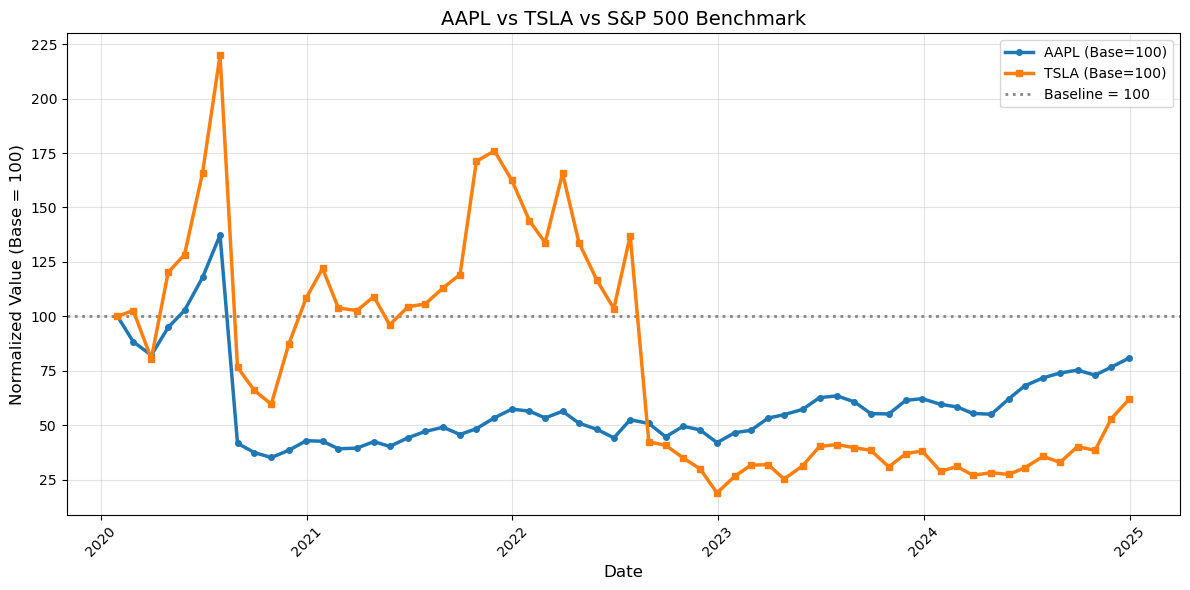

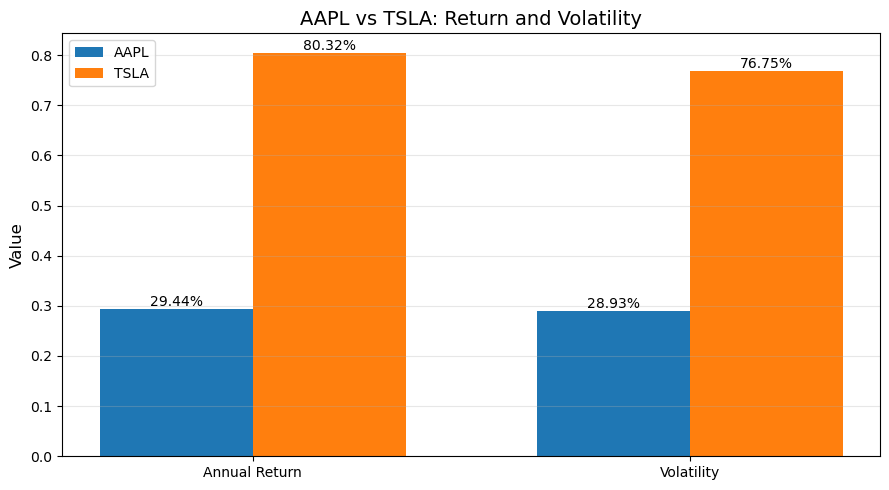


Please choose an option:
1. Analyze one stock
2. Compare two stocks
3. Exit


Enter 1, 2, or 3:  1
Enter stock ticker:  MSFT
Enter start date (YYYY-MM-DD):  2020-01-01



--- Single Stock Analysis Result ---
Company Name: MICROSOFT CORP
Ticker: MSFT
Start Date: 2020-01-01
Annual Return: 23.15%
Annual Volatility: 22.40%
Sharpe Ratio: 0.94
Maximum Drawdown: 30.98%
Return Level: High Return
Risk Level: Medium Risk
Sharpe Ratio Evaluation: Moderate
Drawdown Evaluation: Moderate
Final Suggestion: Hold
Error retrieving S&P 500 data: (psycopg2.errors.InsufficientPrivilege) permission denied for schema crsp_a_indexes

[SQL: 
        SELECT caldt AS date, spindx
        FROM crsp.msp500
        WHERE caldt >= '2020-01-01'
        ORDER BY caldt
    ]
(Background on this error at: https://sqlalche.me/e/20/f405)


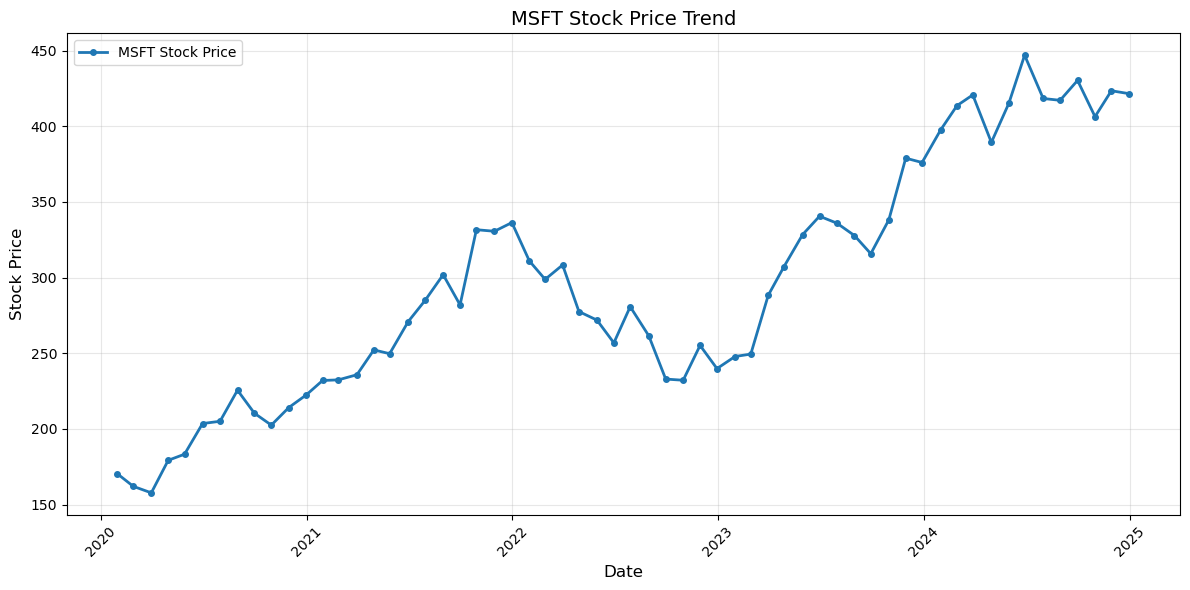

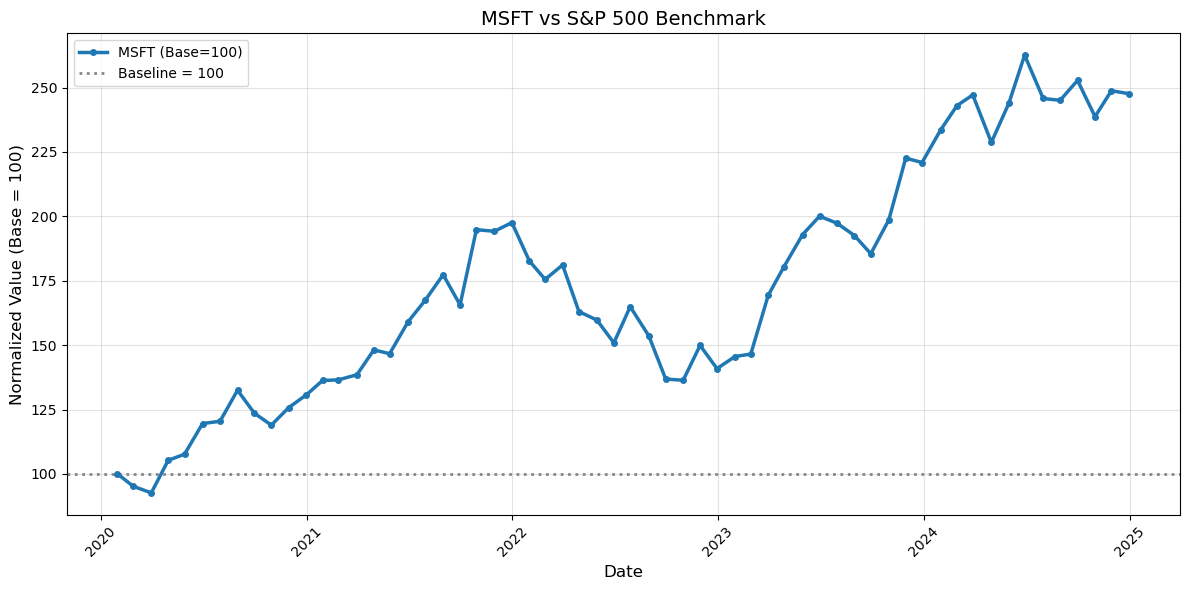

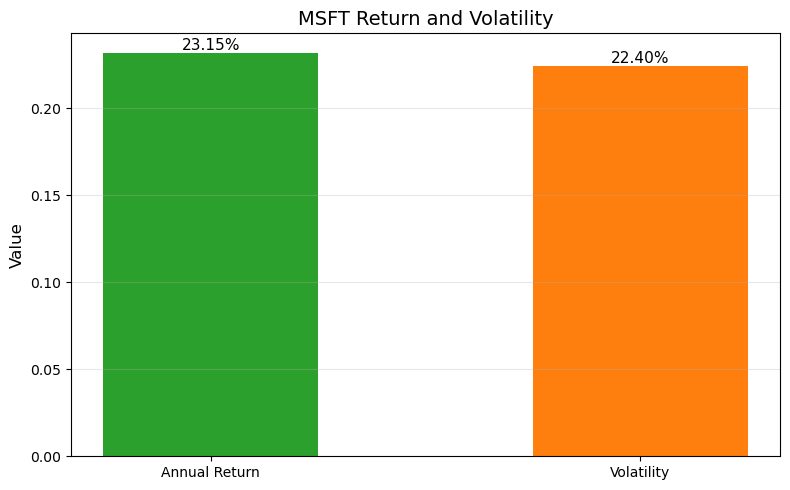


Please choose an option:
1. Analyze one stock
2. Compare two stocks
3. Exit


Enter 1, 2, or 3:  3


Exiting program. Goodbye.


In [6]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------
# 1. Optional company name mapping
# ------------------------------
ticker_to_company = {
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "GOOGL": "Alphabet Inc.",
    "AMZN": "Amazon.com Inc.",
    "TSLA": "Tesla Inc.",
    "NVDA": "NVIDIA Corporation",
    "META": "Meta Platforms Inc."
}


# ------------------------------
# 2. Connect to WRDS
# ------------------------------
def connect_wrds(username):
    """
    Connect to WRDS using the user's WRDS username.
    """
    try:
        db = wrds.Connection(wrds_username=username)
        print("Successfully connected to WRDS.")
        return db
    except Exception as e:
        print(f"Connection failed: {e}")
        return None


# ------------------------------
# 3. Get stock data from CRSP
# ------------------------------
def get_stock_data(db, ticker, start_date="2020-01-01"):
    """
    Retrieve monthly stock data from CRSP for a specific ticker and date range.
    """
    sql_query = f"""
        SELECT 
            a.permno,
            b.ticker,
            b.comnam,
            a.date,
            a.prc,
            a.ret
        FROM crsp.msf AS a
        JOIN crsp.msenames AS b
          ON a.permno = b.permno
        WHERE b.ticker = '{ticker.upper()}'
          AND a.date >= '{start_date}'
          AND a.date BETWEEN b.namedt AND b.nameendt
        ORDER BY a.date
    """

    try:
        stock_data = db.raw_sql(sql_query, date_cols=["date"])
    except Exception as e:
        print(f"Error retrieving stock data for {ticker}: {e}")
        return None

    if stock_data.empty:
        print(f"No data found for ticker {ticker.upper()}.")
        return None

    stock_data = stock_data.rename(columns={
        "prc": "stock_price",
        "ret": "monthly_return",
        "comnam": "company_name"
    })

    stock_data["stock_price"] = stock_data["stock_price"].abs()
    stock_data = stock_data.dropna(subset=["date", "stock_price", "monthly_return"])
    stock_data = stock_data.sort_values(by="date").reset_index(drop=True)

    if stock_data.empty:
        print(f"No valid stock data available for ticker {ticker.upper()}.")
        return None

    return stock_data


# ------------------------------
# 4. Get S&P 500 benchmark data
# ------------------------------
def get_sp500_data(db, start_date="2020-01-01"):
    """
    Retrieve S&P 500 index data from WRDS CRSP database.
    """
    sql_query = f"""
        SELECT caldt AS date, spindx
        FROM crsp.msp500
        WHERE caldt >= '{start_date}'
        ORDER BY caldt
    """

    try:
        sp500 = db.raw_sql(sql_query, date_cols=["date"])
    except Exception as e:
        print(f"Error retrieving S&P 500 data: {e}")
        return None

    if sp500.empty:
        print("No S&P 500 data found.")
        return None

    sp500 = sp500.rename(columns={"spindx": "sp500_index"})
    sp500 = sp500.dropna(subset=["date", "sp500_index"]).sort_values(by="date").reset_index(drop=True)

    return sp500


# ------------------------------
# 5. Normalize data for comparison
# ------------------------------
def normalize_to_base100(series):
    """
    Normalize a series to a base value of 100.
    """
    valid_series = series.dropna()
    if valid_series.empty:
        return series
    return series / valid_series.iloc[0] * 100


# ------------------------------
# 6. Financial metrics calculation
# ------------------------------
def calculate_annual_return(stock_info):
    """
    Calculate annualized return based on average monthly return.
    """
    if stock_info is None or stock_info.empty:
        return None
    return stock_info["monthly_return"].mean() * 12


def calculate_volatility(stock_info):
    """
    Calculate annualized volatility based on monthly return standard deviation.
    """
    if stock_info is None or stock_info.empty:
        return None
    return stock_info["monthly_return"].std() * np.sqrt(12)


def calculate_sharpe_ratio(stock_info, risk_free_rate=0.02):
    """
    Calculate Sharpe ratio using annual return and annual volatility.
    """
    annual_return = calculate_annual_return(stock_info)
    volatility = calculate_volatility(stock_info)

    if annual_return is None or volatility is None or volatility == 0:
        return None

    return (annual_return - risk_free_rate) / volatility


def calculate_max_drawdown(stock_info):
    """
    Calculate maximum drawdown from stock price series.
    """
    if stock_info is None or stock_info.empty:
        return None

    prices = stock_info["stock_price"].dropna()
    if prices.empty:
        return None

    cumulative_max = prices.cummax()
    drawdown = (prices - cumulative_max) / cumulative_max
    return abs(drawdown.min())


# ------------------------------
# 7. Plot original single stock price trend
# ------------------------------
def plot_stock_price(stock_info, ticker):
    """
    Plot the original stock price trend for one company.
    """
    if stock_info is None or stock_info.empty:
        print(f"No data available for {ticker}.")
        return

    stock_plot = stock_info[["date", "stock_price"]].dropna().sort_values(by="date")

    plt.figure(figsize=(12, 6))
    plt.plot(
        stock_plot["date"],
        stock_plot["stock_price"],
        label=f"{ticker.upper()} Stock Price",
        color="#1f77b4",
        linewidth=2,
        marker="o",
        markersize=4
    )

    plt.title(f"{ticker.upper()} Stock Price Trend", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Stock Price", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------
# 8. Plot single stock vs S&P 500 benchmark
# ------------------------------
def plot_stock_price_with_benchmark(stock_info, ticker, sp500_info=None):
    """
    Plot one company's normalized stock trend together with S&P 500 benchmark.
    """
    if stock_info is None or stock_info.empty:
        print(f"No data available for {ticker}.")
        return

    stock_plot = stock_info[["date", "stock_price"]].dropna().sort_values(by="date").copy()
    stock_plot["normalized_price"] = normalize_to_base100(stock_plot["stock_price"])

    plt.figure(figsize=(12, 6))

    plt.plot(
        stock_plot["date"],
        stock_plot["normalized_price"],
        label=f"{ticker.upper()} (Base=100)",
        color="#1f77b4",
        linewidth=2.5,
        marker="o",
        markersize=4,
        zorder=3
    )

    if sp500_info is not None and not sp500_info.empty:
        sp500_plot = sp500_info[["date", "sp500_index"]].dropna().sort_values(by="date").copy()
        sp500_plot["normalized_sp500"] = normalize_to_base100(sp500_plot["sp500_index"])

        plt.plot(
            sp500_plot["date"],
            sp500_plot["normalized_sp500"],
            label="S&P 500 Benchmark (Base=100)",
            color="red",
            linewidth=3,
            linestyle="--",
            zorder=2
        )

    plt.axhline(
        y=100,
        color="gray",
        linestyle=":",
        linewidth=2,
        alpha=0.95,
        label="Baseline = 100"
    )

    plt.title(f"{ticker.upper()} vs S&P 500 Benchmark", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Normalized Value (Base = 100)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.35)
    plt.tight_layout()
    plt.show()


# ------------------------------
# 9. Plot two stocks vs S&P 500 benchmark
# ------------------------------
def plot_two_stock_prices_with_benchmark(stock_info1, ticker1, stock_info2, ticker2, sp500_info=None):
    """
    Plot two companies' normalized stock price trends together with S&P 500 benchmark.
    """
    if stock_info1 is None or stock_info1.empty:
        print(f"No data available for {ticker1}.")
        return

    if stock_info2 is None or stock_info2.empty:
        print(f"No data available for {ticker2}.")
        return

    stock1_plot = stock_info1[["date", "stock_price"]].dropna().sort_values(by="date").copy()
    stock2_plot = stock_info2[["date", "stock_price"]].dropna().sort_values(by="date").copy()

    stock1_plot["normalized_price"] = normalize_to_base100(stock1_plot["stock_price"])
    stock2_plot["normalized_price"] = normalize_to_base100(stock2_plot["stock_price"])

    plt.figure(figsize=(12, 6))

    plt.plot(
        stock1_plot["date"],
        stock1_plot["normalized_price"],
        label=f"{ticker1.upper()} (Base=100)",
        linewidth=2.5,
        marker="o",
        markersize=4,
        zorder=3
    )

    plt.plot(
        stock2_plot["date"],
        stock2_plot["normalized_price"],
        label=f"{ticker2.upper()} (Base=100)",
        linewidth=2.5,
        marker="s",
        markersize=4,
        zorder=3
    )

    if sp500_info is not None and not sp500_info.empty:
        sp500_plot = sp500_info[["date", "sp500_index"]].dropna().sort_values(by="date").copy()
        sp500_plot["normalized_sp500"] = normalize_to_base100(sp500_plot["sp500_index"])

        plt.plot(
            sp500_plot["date"],
            sp500_plot["normalized_sp500"],
            label="S&P 500 Benchmark (Base=100)",
            color="red",
            linewidth=3,
            linestyle="--",
            zorder=2
        )

    plt.axhline(
        y=100,
        color="gray",
        linestyle=":",
        linewidth=2,
        alpha=0.95,
        label="Baseline = 100"
    )

    plt.title(f"{ticker1.upper()} vs {ticker2.upper()} vs S&P 500 Benchmark", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Normalized Value (Base = 100)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.35)
    plt.tight_layout()
    plt.show()


# ------------------------------
# 10. Plot return and volatility for one stock
# ------------------------------
def plot_return_volatility_chart(result):
    """
    Plot annual return and volatility for one company.
    """
    if result is None:
        return

    metrics = ["Annual Return", "Volatility"]
    values = [result["annual_return"], result["volatility"]]

    if any(v is None for v in values):
        print("Insufficient data to plot return and volatility chart.")
        return

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics, values, color=["#2ca02c", "#ff7f0e"], width=0.5)

    plt.title(f"{result['ticker']} Return and Volatility", fontsize=14)
    plt.ylabel("Value", fontsize=12)
    plt.grid(axis="y", alpha=0.3)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2%}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.tight_layout()
    plt.show()


# ------------------------------
# 11. Plot return and volatility comparison for two stocks
# ------------------------------
def plot_comparison_return_volatility(result1, result2):
    """
    Plot annual return and volatility comparison for two companies.
    """
    if result1 is None or result2 is None:
        return

    metrics = ["Annual Return", "Volatility"]
    company1_values = [result1["annual_return"], result1["volatility"]]
    company2_values = [result2["annual_return"], result2["volatility"]]

    if any(v is None for v in company1_values + company2_values):
        print("Insufficient data to plot comparison chart.")
        return

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(9, 5))
    bars1 = plt.bar(x - width / 2, company1_values, width, label=result1["ticker"], color="#1f77b4")
    bars2 = plt.bar(x + width / 2, company2_values, width, label=result2["ticker"], color="#ff7f0e")

    plt.title(f"{result1['ticker']} vs {result2['ticker']}: Return and Volatility", fontsize=14)
    plt.xticks(x, metrics)
    plt.ylabel("Value", fontsize=12)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.2%}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


# ------------------------------
# 12. Classification helpers
# ------------------------------
def classify_return_level(annual_return):
    """
    Classify annual return level.
    """
    if annual_return is None:
        return "Unknown"
    elif annual_return >= 0.15:
        return "High Return"
    elif annual_return >= 0.08:
        return "Medium Return"
    else:
        return "Low Return"


def classify_risk_level(volatility):
    """
    Classify risk level based on annual volatility.
    """
    if volatility is None:
        return "Unknown"
    elif volatility < 0.20:
        return "Low Risk"
    elif volatility < 0.35:
        return "Medium Risk"
    else:
        return "High Risk"


def classify_sharpe_ratio(sharpe_ratio):
    """
    Classify Sharpe ratio quality.
    """
    if sharpe_ratio is None:
        return "Unknown"
    elif sharpe_ratio >= 1:
        return "Good"
    elif sharpe_ratio >= 0.5:
        return "Moderate"
    else:
        return "Poor"


def classify_drawdown(max_drawdown):
    """
    Classify maximum drawdown severity.
    """
    if max_drawdown is None:
        return "Unknown"
    elif max_drawdown < 0.20:
        return "Stable"
    elif max_drawdown < 0.40:
        return "Moderate"
    else:
        return "Severe"


# ------------------------------
# 13. Final investment suggestion
# ------------------------------
def make_investment_suggestion(annual_return, volatility, sharpe_ratio, max_drawdown):
    """
    Generate final investment suggestion.
    """
    if None in [annual_return, volatility, sharpe_ratio, max_drawdown]:
        return "Insufficient Data"

    if annual_return >= 0.15 and volatility < 0.25 and sharpe_ratio >= 1 and max_drawdown < 0.30:
        return "Buy"
    elif annual_return >= 0.08 and sharpe_ratio >= 0.5 and max_drawdown < 0.40:
        return "Hold"
    else:
        return "Not Buy"


# ------------------------------
# 14. Analyze one stock
# ------------------------------
def analyze_stock_investment(db, ticker, start_date="2020-01-01", show_plot=True):
    """
    Perform full analysis for one stock.
    """
    stock_info = get_stock_data(db, ticker, start_date)

    if stock_info is None or stock_info.empty:
        return None

    annual_return = calculate_annual_return(stock_info)
    volatility = calculate_volatility(stock_info)
    sharpe_ratio = calculate_sharpe_ratio(stock_info)
    max_drawdown = calculate_max_drawdown(stock_info)

    return_level = classify_return_level(annual_return)
    risk_level = classify_risk_level(volatility)
    sharpe_judge = classify_sharpe_ratio(sharpe_ratio)
    drawdown_judge = classify_drawdown(max_drawdown)
    suggestion = make_investment_suggestion(annual_return, volatility, sharpe_ratio, max_drawdown)

    if "company_name" in stock_info.columns and not stock_info["company_name"].empty:
        company_name = stock_info["company_name"].iloc[0]
    else:
        company_name = ticker_to_company.get(ticker.upper(), "Unknown Company")

    result = {
        "company_name": company_name,
        "ticker": ticker.upper(),
        "start_date": start_date,
        "annual_return": annual_return,
        "volatility": volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown,
        "return_level": return_level,
        "risk_level": risk_level,
        "sharpe_judge": sharpe_judge,
        "drawdown_judge": drawdown_judge,
        "suggestion": suggestion,
        "stock_data": stock_info
    }

    print("\n--- Single Stock Analysis Result ---")
    print(f"Company Name: {result['company_name']}")
    print(f"Ticker: {result['ticker']}")
    print(f"Start Date: {result['start_date']}")
    print(f"Annual Return: {result['annual_return']:.2%}" if result["annual_return"] is not None else "Annual Return: N/A")
    print(f"Annual Volatility: {result['volatility']:.2%}" if result["volatility"] is not None else "Annual Volatility: N/A")
    print(f"Sharpe Ratio: {result['sharpe_ratio']:.2f}" if result["sharpe_ratio"] is not None else "Sharpe Ratio: N/A")
    print(f"Maximum Drawdown: {result['max_drawdown']:.2%}" if result["max_drawdown"] is not None else "Maximum Drawdown: N/A")
    print(f"Return Level: {result['return_level']}")
    print(f"Risk Level: {result['risk_level']}")
    print(f"Sharpe Ratio Evaluation: {result['sharpe_judge']}")
    print(f"Drawdown Evaluation: {result['drawdown_judge']}")
    print(f"Final Suggestion: {result['suggestion']}")

    if show_plot:
        sp500_info = get_sp500_data(db, start_date)

        # 1. Original stock price trend
        plot_stock_price(stock_info, ticker.upper())

        # 2. Stock vs S&P 500 benchmark
        plot_stock_price_with_benchmark(stock_info, ticker.upper(), sp500_info)

        # 3. Return and volatility chart
        plot_return_volatility_chart(result)

    return result


# ------------------------------
# 15. Compare two stocks
# ------------------------------
def compare_two_stocks(db, ticker1, ticker2, start_date="2020-01-01", show_plot=True):
    """
    Compare two stocks side by side.
    """
    result1 = analyze_stock_investment(db, ticker1, start_date, show_plot=False)
    result2 = analyze_stock_investment(db, ticker2, start_date, show_plot=False)

    if result1 is None or result2 is None:
        print("Comparison failed because one or both stocks have no valid data.")
        return None

    comparison_df = pd.DataFrame({
        "Metric": ["Annual Return", "Volatility", "Sharpe Ratio", "Maximum Drawdown", "Suggestion"],
        result1["ticker"]: [
            f"{result1['annual_return']:.2%}" if result1["annual_return"] is not None else "N/A",
            f"{result1['volatility']:.2%}" if result1["volatility"] is not None else "N/A",
            f"{result1['sharpe_ratio']:.2f}" if result1["sharpe_ratio"] is not None else "N/A",
            f"{result1['max_drawdown']:.2%}" if result1["max_drawdown"] is not None else "N/A",
            result1["suggestion"]
        ],
        result2["ticker"]: [
            f"{result2['annual_return']:.2%}" if result2["annual_return"] is not None else "N/A",
            f"{result2['volatility']:.2%}" if result2["volatility"] is not None else "N/A",
            f"{result2['sharpe_ratio']:.2f}" if result2["sharpe_ratio"] is not None else "N/A",
            f"{result2['max_drawdown']:.2%}" if result2["max_drawdown"] is not None else "N/A",
            result2["suggestion"]
        ]
    })

    print("\n--- Two-Stock Comparison Result ---")
    print(comparison_df.to_string(index=False))

    if show_plot:
        sp500_info = get_sp500_data(db, start_date)
        plot_two_stock_prices_with_benchmark(
            result1["stock_data"], ticker1.upper(),
            result2["stock_data"], ticker2.upper(),
            sp500_info
        )
        plot_comparison_return_volatility(result1, result2)

    return comparison_df


# ------------------------------
# 16. Validate date format
# ------------------------------
def is_valid_date(date_text):
    """
    Check whether the date is in YYYY-MM-DD format.
    """
    try:
        pd.to_datetime(date_text, format="%Y-%m-%d")
        return True
    except ValueError:
        return False


# ------------------------------
# 17. Main interactive program
# ------------------------------
def run_stock_analysis_program():
    """
    Main interactive stock analysis program.
    """
    print("Welcome to the Stock Investment Analysis Program")

    username = input("Please enter your WRDS username: ").strip()
    if username == "":
        print("WRDS username cannot be empty.")
        return

    db = connect_wrds(username)

    if db is None:
        print("Program terminated because WRDS connection failed.")
        return

    while True:
        print("\nPlease choose an option:")
        print("1. Analyze one stock")
        print("2. Compare two stocks")
        print("3. Exit")

        choice = input("Enter 1, 2, or 3: ").strip()

        if choice == "1":
            ticker = input("Enter stock ticker: ").strip().upper()
            start_date = input("Enter start date (YYYY-MM-DD): ").strip()

            if ticker == "":
                print("Ticker cannot be empty.")
                continue

            if not is_valid_date(start_date):
                print("Invalid date format. Please use YYYY-MM-DD.")
                continue

            analyze_stock_investment(db, ticker, start_date, show_plot=True)

        elif choice == "2":
            ticker1 = input("Enter first stock ticker: ").strip().upper()
            ticker2 = input("Enter second stock ticker: ").strip().upper()
            start_date = input("Enter start date (YYYY-MM-DD): ").strip()

            if ticker1 == "" or ticker2 == "":
                print("Tickers cannot be empty.")
                continue

            if not is_valid_date(start_date):
                print("Invalid date format. Please use YYYY-MM-DD.")
                continue

            compare_two_stocks(db, ticker1, ticker2, start_date, show_plot=True)

        elif choice == "3":
            print("Exiting program. Goodbye.")
            try:
                db.close()
            except Exception:
                pass
            break

        else:
            print("Invalid input. Please try again.")


# ------------------------------
# 18. Program entry point
# ------------------------------
if __name__ == "__main__":
    run_stock_analysis_program()